In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from model.classifier import Classifier, MyProgressBar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.set_float32_matmul_precision('high')

In [3]:
from utils.transform_sequence import TransformSequence
from utils.transforms.apply import grid_resample
from utils.affine_transforms import AffineTransformation2D

transformations = [AffineTransformation2D.ROTATION_COMPLEX.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)

In [4]:
from its.transform import multi_transform
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.




def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)


# Create transformed datasets for both training and testing
dataset_train_transformed = AffineTransformDataset(dataset_train, transform, return_transformation=False, batch_size=batch_size)


In [5]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)

# Create data loader for transformed training data
train_transformed_loader = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)


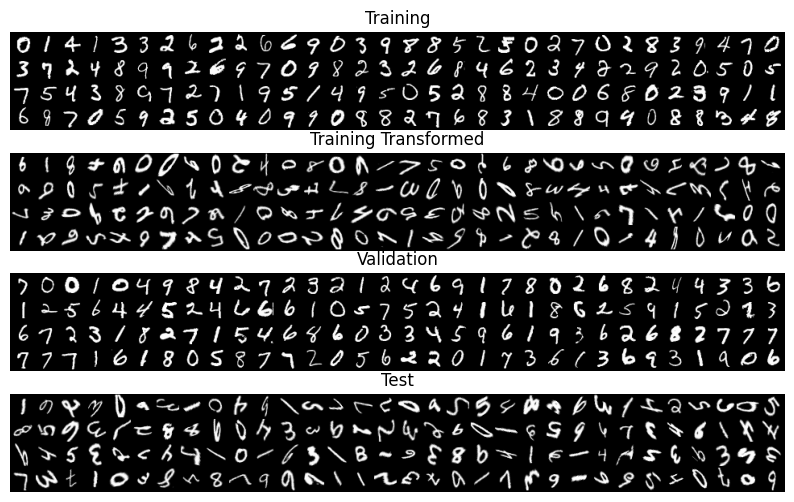

In [6]:
#test images
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10, 6))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(train_transformed_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[3].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Training Transformed')
axs[2].set_title('Validation')
axs[3].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [7]:
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}.pth'

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Loading model from ../model/mnist.pth


In [8]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [9]:
model.cuda()


Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [10]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9894.


In [11]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'9',flatten=True)

In [12]:
#extract embeddings and fit NNDistanceConfidence()
embeddings = []
classes = []
for batch in train_loader:
    emb, _ = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())

embeddings = np.vstack(embeddings)
classes = np.hstack(classes)

#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings = embeddings[indices]
    classes = classes[indices]



In [13]:
from confidence.base_confidence import CrossEntropyConfidence,EnergyConfidence
from confidence.unsupervised.ml.nn_pytorch import TorchNNConfidence
from utils.transformation_problem import TransformationProblem

In [14]:
nearest_neighbor_confidence = TorchNNConfidence(per_class=True,number_of_neighbors=3)
nearest_neighbor_confidence.fit(torch.tensor(embeddings, dtype=torch.float,device="cuda"),torch.tensor(classes, dtype=torch.float,device="cuda"))
nearest_neighbor_confidence.cuda()
from confidence.base_confidence import SplitConfidence, SinglePassConfidence
nearest_neighbor_confidence_unguided = TorchNNConfidence(per_class=False,number_of_neighbors=3)
nearest_neighbor_confidence_unguided.fit(embeddings)
nearest_neighbor_confidence_unguided.cuda()


conf_split_guided = SplitConfidence(nearest_neighbor_confidence, CrossEntropyConfidence(), mult=True)
conf_split_unguided = SplitConfidence(nearest_neighbor_confidence_unguided, EnergyConfidence(), mult=True)

In [15]:

conf_guided = SinglePassConfidence(dual_ouput_model, conf_split_guided,index=1)
conf_unguided = SinglePassConfidence(dual_ouput_model, conf_split_unguided,index=1)
problem_guided = TransformationProblem(conf_guided, transform_seq, consolidate_method="consolidate_simple")

problem_unguided = TransformationProblem(conf_unguided, transform_seq, consolidate_method="consolidate_simple")


In [16]:
nearest_neighbor_confidence._train_data = nearest_neighbor_confidence._train_data.cuda()

In [17]:
model.cuda()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [18]:
import search.shgo
import importlib
import tqdm

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk")
test_acc_sim = 0
stop_at = 1
counter = 0
regression_data = []
regression_target =[]
regression_classes = []

for d, (data, target) in enumerate(tqdm.tqdm(train_transformed_loader)):
    data, target = data.cuda(), target.cuda()
    regression_data.append(data.detach().cpu().numpy())
    res = di.optimize(problem_guided, data.cuda(),y=target.cuda())
    regression_target.append(res[0].detach().cpu().numpy())
    regression_classes.append(target.detach().cpu().numpy())

    # Apply the transformation and get predictions
    x_transformed2 = problem_guided.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'With class knowledge we can define a canonical represenation of the data: {test_acc_sim}.')

100%|██████████| 469/469 [02:47<00:00,  2.80it/s]

With class knowledge we can define a canonical represenation of the data: 0.9999166666666667.


In [19]:
regression_target = np.vstack(regression_target)
regression_target = torch.tensor(regression_target, dtype=torch.float32).cpu()
regression_data = np.vstack(regression_data)
regression_data = torch.tensor(regression_data, dtype=torch.float32).cpu()
regression_classes = np.hstack(regression_classes)
regression_classes = torch.tensor(regression_classes, dtype=torch.long).cpu()



In [20]:
#this is very unlikely to work due to noise and symetires.

In [21]:

class RegressionDataset(torch.utils.data.Dataset):
    def __init__(self, data, target_params,y=None):
        self.data = data
        self.target_params = target_params
        self.y = y

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        target_params = self.target_params[idx]
        if self.y is not None:
            y = self.y[idx]
            return x, target_params, y
        else:
            return x, target_params


In [22]:
regression_dataset = RegressionDataset(regression_data, regression_target, regression_classes)
regression_dataloader = torch.utils.data.DataLoader(regression_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

(-0.5, 301.5, 301.5, -0.5)

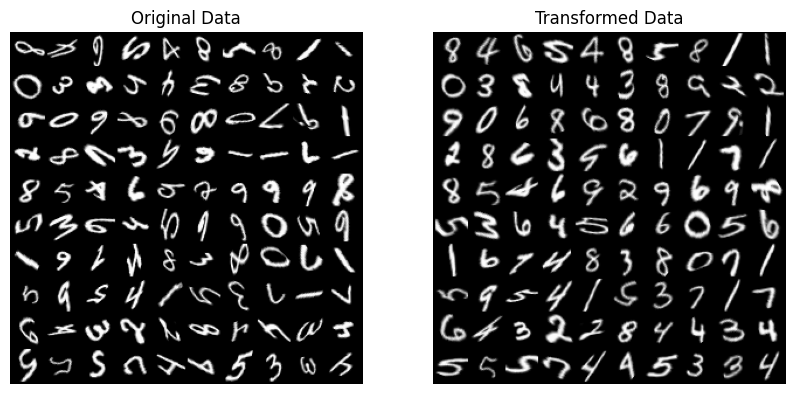

In [23]:
#plot dataset and transformed dataset sample

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
x,p,_ = regression_dataset[:100]

plt.imshow(torchvision.utils.make_grid(x, nrow=10).permute(1, 2, 0).cpu())
plt.title('Original Data')
plt.axis('off')

plt.subplot(1, 2, 2)

x_transformed = transform_seq.transform(x, p)
plt.imshow(torchvision.utils.make_grid(x_transformed, nrow=10).permute(1, 2, 0).cpu())
plt.title('Transformed Data')
plt.axis('off')





In [24]:
# Define localization network for spatial transformer
localization_net = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.GELU(),

)

# Calculate the output dimension of the localization network
with torch.no_grad():
    dummy_input = torch.zeros(1, 1, 28, 28)
    loc_output = localization_net(dummy_input)
    localization_dim = loc_output.numel()  # Get the flattened size
    print(f"Localization network output dimension: {localization_dim}")

# Create spatial transformer model (6 parameters for 2D affine transformation)
spatial_model_path = f'../model/{dataset}_gmm_reg4.py'

Localization network output dimension: 128


In [25]:




from utils.transformation_problem import TransformationProblem


from model.pspatial.m_p_spatial import TrainModeSchedulerCallback
from model.pspatial.f_spatial import FlowProbSpatialTransformerClassifier



# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and False:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = FlowProbSpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    spatial_transformer = FlowProbSpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-3},
        optimizer_class = torch.optim.AdamW,
        l2_weight= 0.01,
        kl_weight=1e-12,
        use_l2_instead_of_per_transform = False,
        train_mode = 1.0,
        num_flows=3,
        flow_hidden_units=256,
    )
    train_mode_scheduler = TrainModeSchedulerCallback(
        regression_epochs=30,
        transition_epochs=10,
    )
    restore_best_model = pl.callbacks.ModelCheckpoint(
        monitor='val_acc_mode',
        mode='max',
        save_top_k=1,
        verbose=True,
        filename='best_fspatial_transformer',
    )

    # Train the spatial transformer model on transformed data
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=40,
        precision="16-mixed",
        callbacks=[MyProgressBar(), train_mode_scheduler, restore_best_model],
        enable_checkpointing=True,
    )

    trainer.fit(spatial_transformer, regression_dataloader, test_loader)
    #restore best checkpoint
    best_ckpt_path = restore_best_model.best_model_path
    print(f"Loading best model checkpoint from: {best_ckpt_path}")
    spatial_transformer = FlowProbSpatialTransformerClassifier.load_from_checkpoint(best_ckpt_path)


    # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")


Using 16bit Automatic Mixed Precision (AMP)


Training spatial transformer model and will save to ../model/mnist_gmm_reg4.py


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                       | Params | Mode 
------------------------------------------------------------------------
0 | main_model       | Sequential                 | 421 K  | eval 
1 | localization_net | Sequential                 | 420 K  | train
2 | flow             | ConditionalNormalizingFlow | 1.1 M  | train
------------------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.798     Total estimated model params size (MB)
91        Modules in train mode
11        Modules in eval mode


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 469/469 [00:34<00:00, 13.47it/s, v_num=167, val_loss=2.510, val_acc_sampled=0.662, val_acc_mode=0.903, train_mode_scheduled=1.000, train_loss=0.212]

...

Epoch 12: 100%|██████████| 469/469 [00:32<00:00, 14.46it/s, v_num=167, val_loss=1.140, val_acc_sampled=0.837, val_acc_mode=0.933, train_mode_scheduled=1.000, train_loss=-2.24]

Epoch 12, global step 6097: 'val_acc_mode' was not in top 1


Epoch 13: 100%|██████████| 469/469 [00:33<00:00, 14.12it/s, v_num=167, val_loss=1.140, val_acc_sampled=0.837, val_acc_mode=0.933, train_mode_scheduled=1.000, train_loss=-2.24]
Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [26]:




from utils.transformation_problem import TransformationProblem


from model.pspatial.m_p_spatial import TrainModeSchedulerCallback
from model.pspatial.f_spatial import FlowProbSpatialTransformerClassifier



# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and False:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = FlowProbSpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    spatial_transformer = FlowProbSpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-3},
        optimizer_class = torch.optim.AdamW,
        l2_weight= 0.01,
        kl_weight=1e-12,
        use_l2_instead_of_per_transform = False,
        train_mode = 1.0,
        num_flows=3,
        flow_hidden_units=256,
    )
    train_mode_scheduler = TrainModeSchedulerCallback(
        regression_epochs=30,
        transition_epochs=10,
    )
    restore_best_model = pl.callbacks.ModelCheckpoint(
        monitor='val_acc_mode',
        mode='max',
        save_top_k=1,
        verbose=True,
        filename='best_fspatial_transformer',
    )

    # Train the spatial transformer model on transformed data
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=40,
        precision="16-mixed",
        callbacks=[MyProgressBar(), train_mode_scheduler, restore_best_model],
        enable_checkpointing=True,
    )

    trainer.fit(spatial_transformer, regression_dataloader, test_loader)
    #restore best checkpoint
    best_ckpt_path = restore_best_model.best_model_path
    print(f"Loading best model checkpoint from: {best_ckpt_path}")
    spatial_transformer = FlowProbSpatialTransformerClassifier.load_from_checkpoint(best_ckpt_path)


    # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                       | Params | Mode 
------------------------------------------------------------------------
0 | main_model       | Sequential                 | 421 K  | eval 
1 | localization_net | Sequential                 | 420 K  | eval 
2 | flow             | ConditionalNormalizingFlow | 1.1 M  | train
------------------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.798     Total estimated model params size (MB)
81        Modules in train mode
21        Modules in eval mode


Training spatial transformer model and will save to ../model/mnist_gmm_reg4.py
Epoch 0: 100%|██████████| 469/469 [00:35<00:00, 13.25it/s, v_num=168, val_loss=1.610, val_acc_sampled=0.774, val_acc_mode=0.913, train_mode_scheduled=1.000, train_loss=-0.529]

Epoch 0, global step 469: 'val_acc_mode' reached 0.91260 (best 0.91260), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\lightning_logs\\version_168\\checkpoints\\best_fspatial_transformer.ckpt' as top 1


Epoch 1: 100%|██████████| 469/469 [00:33<00:00, 13.87it/s, v_num=168, val_loss=1.370, val_acc_sampled=0.807, val_acc_mode=0.919, train_mode_scheduled=1.000, train_loss=-1.40] 

Epoch 1, global step 938: 'val_acc_mode' reached 0.91860 (best 0.91860), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\lightning_logs\\version_168\\checkpoints\\best_fspatial_transformer.ckpt' as top 1


...

Epoch 2, global step 1407: 'val_acc_mode' reached 0.92240 (best 0.92240), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\lightning_logs\\version_168\\checkpoints\\best_fspatial_transformer.ckpt' as top 1


Epoch 3:  16%|█▌        | 73/469 [00:05<00:27, 14.57it/s, v_num=168, val_loss=1.520, val_acc_sampled=0.799, val_acc_mode=0.922, train_mode_scheduled=1.000, train_loss=-1.72] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


Epoch 13: 100%|██████████| 469/469 [02:25<00:00,  3.21it/s, v_num=167, val_loss=1.140, val_acc_sampled=0.837, val_acc_mode=0.933, train_mode_scheduled=1.000, train_loss=-2.24]


NameError: name 'exit' is not defined

In [ ]:
spatial_transformer.cuda()

In [32]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer.transform_input(data)
        logits = model(output)
        st_acc += logits.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')


Spatial transformer accuracy on the transformed test set: 0.9098.


In [33]:
import hashlib


def hash_model(model):
    """Compute a SHA256 hash of a PyTorch model's state_dict."""
    # Get the state_dict
    state_dict = model.state_dict()

    # Serialize the state_dict into a single bytes object
    serialized = b"".join(
        tensor.cpu().numpy().tobytes() for tensor in state_dict.values()
    )

    # Compute hash
    return hashlib.sha256(serialized).hexdigest()

In [34]:
hash_model(spatial_transformer.cuda())

'2496d60acc48e028edf4518adf7729cfd173ea900d5fc2ee4d60249daa77fabb'

In [35]:
opt = spatial_transformer.configure_optimizers()

In [37]:
spatial_transformer.conf_module = conf_guided

In [39]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer.transform_input(data)
        logits = model(output)
        st_acc += logits.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')


Spatial transformer accuracy on the transformed test set: 0.8688.


In [ ]:
spatial_transformer.l2_weight=1.0
spatial_transformer.kl_weight=1e-8

In [ ]:
trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[MyProgressBar()]
    )

In [ ]:
trainer.fit(spatial_transformer,train_transformed_loader,test_loader)


In [ ]:
spatial_transformer.cuda()

In [ ]:
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda(), target.cuda()

    # 2. Apply spatial transformer
    transformed = spatial_transformer.transform_input(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red = torch.tensor((194, 80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:, 0, :] = color
        img[:, -1, :] = color
        img[:, :, 0] = color
        img[:, :, -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer (framed)')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer.transform_input(data)
        logits = model(output)
        st_acc += logits.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')


In [ ]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    confs =[]
    correct =[]
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        data_transformed = spatial_transformer.transform_input(data)
        conf,output = conf_unguided(data_transformed)
        confs.append(conf.cpu().numpy())
        same =output.argmax(dim=-1).eq(target)
        correct.append(same.cpu().numpy())
        st_acc += same.sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

In [ ]:
correct = np.hstack(correct)
confs = np.hstack(confs)

confs_correct = confs[correct]
confs_incorrect = confs[~correct]

In [ ]:
plt.hist(confs_correct, bins=50, alpha=0.5, label='Correct')
plt.hist(confs_incorrect, bins=50, alpha=0.5, label='Incorrect')

In [ ]:
conf_search = []
correct_search = []

In [ ]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        best_param,best_error,best_class = di.optimize(problem_unguided, data.cuda())
        conf_search.append(-best_error.cpu().numpy())
        same =best_class.squeeze(-1).eq(target)
        correct_search.append(same.cpu().numpy())
        st_acc += same.sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

In [ ]:
conf_search = np.hstack(conf_search)
correct_search = np.hstack(correct_search)
conf_search_correct = conf_search[correct_search]
conf_search_incorrect = conf_search[~correct_search]

In [ ]:
plt.hist(conf_search_correct, bins=50, alpha=0.5, label='Correct')
plt.hist(confs_correct, bins=50, alpha=0.5, label='Correct Non Search')
plt.hist(conf_search_incorrect, bins=50, alpha=0.5, label='Incorrect')
plt.hist(confs_incorrect, bins=50, alpha=0.5, label='Incorrect Non Search')

In [ ]:
def find_optimal_threshold(correct1, correct2, confidence1, cost_classifier2=0.0):
    thresholds = np.linspace(0, 1, 1000)
    best_acc = 0
    best_thresh = 0
    best_usage = 0

    for t in thresholds:
        use_classifier1 = confidence1 >= t
        use_classifier2 = ~use_classifier1

        correct = (use_classifier1 & correct1) | (use_classifier2 & correct2)
        accuracy = np.mean(correct) - cost_classifier2 * np.mean(use_classifier2)
        usage_rate = np.mean(use_classifier2)  # or use np.sum(use_classifier2) for count

        if accuracy > best_acc:
            best_acc = accuracy
            best_thresh = t
            best_usage = usage_rate

    return best_thresh, best_acc, best_usage

In [ ]:
find_optimal_threshold(correct, correct_search, confs, cost_classifier2=0.00)

In [ ]:
(confs >= 0.02).mean()